# Relational model comparison

This notebook compares relational and entity-history representations for three-second instrument-set anticipation on CAT-SG. All cohort decisions, labels, splits and seeds are imported from notebook 1.

## 1. Frozen inputs and comparison contract

The entity GRU and temporal GNN receive the same 25 annotated frames for every event. The GRU sees visible entities only. The GNN additionally receives typed geometric and semantic relations. A no-edge control retains the graph branch without relation edges. A shuffled-edge control retains relation counts and types but replaces endpoints within each frame.

Targets are multi-hot instrument sets. Neural models use binary cross-entropy; evaluation uses Recall@1, Recall@3 and sample-averaged mean average precision. Validation selects the count baseline and stopping epoch. Test data are evaluated once after those choices are fixed.

In [1]:
import copy
from collections import Counter, defaultdict
from pathlib import Path
import json
import os
import time
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
import torch
import torch.nn as nn
from torch_geometric.nn import RGCNConv, global_mean_pool

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results" / "task_protocol.json").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data" / "annotations"
RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_ROOT = PROJECT_ROOT / "figures"

with (RESULTS_ROOT / "task_protocol.json").open() as file_handle:
    protocol = json.load(file_handle)
events = pd.read_csv(RESULTS_ROOT / "anticipation_events.csv")
for column in ["all_targets", "targets"]:
    events[column] = events[column].map(json.loads)

TARGETS = protocol["eligible_targets"]
TARGET_INDEX = {target: index for index, target in enumerate(TARGETS)}
SEEDS = protocol["seeds"]
T = protocol["observation_seconds"] * protocol["annotation_fps"]
SPLITS = ["train", "val", "test"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(8, os.cpu_count() or 1))

assert SEEDS == [7, 21, 73]
assert events["target_count"].ge(1).all()
assert not events.duplicated(["split", "procedure", "event_frame"]).any()
print(f"{len(events):,} event sets | {len(TARGETS)} targets | device: {DEVICE}")

1,016 event sets | 13 targets | device: cpu


## 2. Observation windows and graph vocabulary

Entity and relation vocabularies are derived from training procedures only. Geometric proximity is represented bidirectionally. Each directed semantic predicate receives a separate inverse type, preserving the distinction between, for example, an instrument holding tissue and tissue being held by an instrument. Surgical step, technique, position and size are deliberately excluded.

In [2]:
train_procedures = sorted(events.query("split == 'train'")["procedure"].unique())
entity_names, predicate_names = set(), set()

for procedure in train_procedures:
    with (DATA_ROOT / "all" / f"{procedure}.json").open() as file_handle:
        payload = json.load(file_handle)
    for frame in payload.values():
        entity_names.update(frame["entities"])
        predicate_names.update(relation[1] for relation in frame["semantic_relations"])

ENTITIES = sorted(entity_names)
PREDICATES = sorted(predicate_names)
RELATIONS = ["Close to"] + PREDICATES + [f"{predicate} (inverse)" for predicate in PREDICATES]
ENTITY_INDEX = {entity: index for index, entity in enumerate(ENTITIES)}
RELATION_INDEX = {relation: index for index, relation in enumerate(RELATIONS)}

print(f"{len(ENTITIES)} training entities | {len(RELATIONS)} directed relation types")
print(RELATIONS)

28 training entities | 15 directed relation types
['Close to', 'Activation', 'Cutting', 'Holding', 'Inserting', 'Pulling', 'Pushing', 'Retracting', 'Activation (inverse)', 'Cutting (inverse)', 'Holding (inverse)', 'Inserting (inverse)', 'Pulling (inverse)', 'Pushing (inverse)', 'Retracting (inverse)']


In [3]:
def encode_frame(frame):
    visible = sorted(entity for entity in frame["entities"] if entity in ENTITY_INDEX)
    local_index = {entity: index for index, entity in enumerate(visible)}
    node_ids = [ENTITY_INDEX[entity] for entity in visible]
    edges = []

    for source, target in frame["geometric_relations"]:
        if source in local_index and target in local_index:
            relation = RELATION_INDEX["Close to"]
            edges.extend(
                [(local_index[source], local_index[target], relation),
                 (local_index[target], local_index[source], relation)]
            )

    for source, predicate, target in frame["semantic_relations"]:
        if source in local_index and target in local_index and predicate in RELATION_INDEX:
            edges.extend(
                [(local_index[source], local_index[target], RELATION_INDEX[predicate]),
                 (local_index[target], local_index[source], RELATION_INDEX[f"{predicate} (inverse)"])]
            )

    return node_ids, edges


def build_examples(split_events):
    examples = []
    for procedure, procedure_events in split_events.groupby("procedure", sort=False):
        with (DATA_ROOT / "all" / f"{procedure}.json").open() as file_handle:
            payload = json.load(file_handle)
        ordered = sorted(((int(key), value) for key, value in payload.items()), key=lambda item: item[0])
        frame_numbers = [number for number, _ in ordered]
        frame_records = [record for _, record in ordered]
        frame_index = {number: index for index, number in enumerate(frame_numbers)}

        for event in procedure_events.itertuples(index=False):
            start = frame_index[event.observation_start_frame]
            end = frame_index[event.observation_end_frame]
            window = frame_records[start:end + 1]
            assert len(window) == T, (procedure, event.event_frame, len(window))

            entity_history = torch.zeros(T, len(ENTITIES), dtype=torch.float32)
            graph_frames = []
            previous_entities = set(window[0]["entities"])
            context = ()

            for time_index, frame in enumerate(window):
                for entity in frame["entities"]:
                    if entity in ENTITY_INDEX:
                        entity_history[time_index, ENTITY_INDEX[entity]] = 1.0
                graph_frames.append(encode_frame(frame))

                if time_index > 0:
                    introduced = set(frame["entities"]).difference(previous_entities)
                    introduced_targets = tuple(sorted(introduced.intersection(TARGET_INDEX)))
                    if introduced_targets:
                        context = introduced_targets
                    previous_entities = set(frame["entities"])

            target_vector = torch.zeros(len(TARGETS), dtype=torch.float32)
            target_vector[[TARGET_INDEX[target] for target in event.targets]] = 1.0
            examples.append(
                {
                    "x": entity_history,
                    "graph_frames": graph_frames,
                    "y": target_vector,
                    "context": context,
                    "procedure": procedure,
                    "multi_instrument": bool(event.multi_instrument),
                }
            )
    return examples


EXAMPLES = {split: build_examples(events.query("split == @split")) for split in SPLITS}
print({split: len(examples) for split, examples in EXAMPLES.items()})
print("multi-instrument:", {split: sum(e["multi_instrument"] for e in examples) for split, examples in EXAMPLES.items()})

{'train': 520, 'val': 135, 'test': 361}
multi-instrument: {'train': 17, 'val': 6, 'test': 11}


## 3. Count baselines

The frequency baseline ranks instruments by training-set onset frequency. The Markov baseline conditions those counts on the most recent set of eligible instruments introduced within the observation window and falls back to the marginal ranking for unseen contexts. Both may rank multiple instruments; no threshold is fitted.

In [4]:
def fit_count_baselines(train_examples):
    marginal = Counter()
    transitions = defaultdict(Counter)
    for example in train_examples:
        target_indices = torch.where(example["y"] > 0)[0].tolist()
        marginal.update(target_indices)
        transitions[example["context"]].update(target_indices)
    return marginal, transitions


MARGINAL, TRANSITIONS = fit_count_baselines(EXAMPLES["train"])
MARGINAL_SCORES = np.array([MARGINAL[index] for index in range(len(TARGETS))], dtype=float)
MARGINAL_PRIOR = MARGINAL_SCORES / MARGINAL_SCORES.sum()

def baseline_scores(kind, examples):
    rows = []
    for example in examples:
        if kind == "markov" and example["context"] in TRANSITIONS:
            counts = TRANSITIONS[example["context"]]
            rows.append(np.array([counts[index] for index in range(len(TARGETS))]) + MARGINAL_PRIOR)
        else:
            rows.append(MARGINAL_SCORES)
    return torch.tensor(np.stack(rows), dtype=torch.float32)

print(f"{len(TRANSITIONS)} Markov contexts observed in training")

31 Markov contexts observed in training


## 4. Shared batches and edge control

Examples are collated once into fixed batches. The no-edge control removes every edge while retaining the relational architecture. The shuffled-edge control redraws endpoints from entities visible in the same frame while preserving the number and type of directed edges. A separate deterministic shuffle is created for each seed and split.

In [5]:
BATCH_SIZE = 64

def make_batches(examples, shuffle_seed=None):
    order = np.arange(len(examples))
    if shuffle_seed is not None:
        np.random.default_rng(shuffle_seed).shuffle(order)
    ordered_examples = [examples[index] for index in order]
    batches = []

    for batch_start in range(0, len(ordered_examples), BATCH_SIZE):
        chunk = ordered_examples[batch_start:batch_start + BATCH_SIZE]
        node_ids, graph_ids, edge_rows = [], [], []
        graph_starts, graph_sizes = [], []

        for sample_index, example in enumerate(chunk):
            for time_index, (frame_nodes, frame_edges) in enumerate(example["graph_frames"]):
                graph_starts.append(len(node_ids))
                graph_sizes.append(len(frame_nodes))
                node_ids.extend(frame_nodes)
                graph_ids.extend([sample_index * T + time_index] * len(frame_nodes))
                base = graph_starts[-1]
                edge_rows.extend((base + source, base + target, relation) for source, target, relation in frame_edges)

        if edge_rows:
            edge_array = torch.tensor(edge_rows, dtype=torch.long)
            edge_index = edge_array[:, :2].T.contiguous()
            edge_type = edge_array[:, 2]
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_type = torch.empty(0, dtype=torch.long)

        batches.append(
            {
                "x": torch.stack([example["x"] for example in chunk]),
                "y": torch.stack([example["y"] for example in chunk]),
                "multi": torch.tensor([example["multi_instrument"] for example in chunk]),
                "procedures": [example["procedure"] for example in chunk],
                "node_ids": torch.tensor(node_ids, dtype=torch.long),
                "graph_ids": torch.tensor(graph_ids, dtype=torch.long),
                "edge_index": edge_index,
                "edge_type": edge_type,
                "graph_starts": torch.tensor(graph_starts, dtype=torch.long),
                "graph_sizes": torch.tensor(graph_sizes, dtype=torch.long),
                "n": len(chunk),
            }
        )
    return batches


BATCHES = {
    "train": make_batches(EXAMPLES["train"], shuffle_seed=0),
    "val": make_batches(EXAMPLES["val"]),
    "test": make_batches(EXAMPLES["test"]),
}
NO_EDGE_BATCHES = {
    split: [{**batch, "edge_index": torch.empty((2, 0), dtype=torch.long),
             "edge_type": torch.empty(0, dtype=torch.long)} for batch in batches]
    for split, batches in BATCHES.items()
}

def shuffled_edges(batch, seed):
    if batch["edge_index"].numel() == 0:
        return batch
    rng = np.random.default_rng(seed)
    edge_graph = batch["graph_ids"][batch["edge_index"][0]].numpy()
    starts = batch["graph_starts"][edge_graph].numpy()
    sizes = batch["graph_sizes"][edge_graph].numpy()
    assert np.all(sizes >= 2)
    source_local = rng.integers(0, sizes)
    target_local = rng.integers(0, sizes - 1)
    target_local += target_local >= source_local
    rewired = torch.tensor(np.stack([starts + source_local, starts + target_local]), dtype=torch.long)
    return {**batch, "edge_index": rewired}


def make_control_batches(seed):
    return {
        split: [shuffled_edges(batch, seed * 10_000 + split_index * 100 + batch_index)
                for batch_index, batch in enumerate(BATCHES[split])]
        for split_index, split in enumerate(SPLITS)
    }

print({split: len(batches) for split, batches in BATCHES.items()})

{'train': 9, 'val': 3, 'test': 6}


## 5. Entity and relational sequence models

Both neural conditions use a 64-unit GRU and the same output head. The relational model preserves the complete entity-presence vector, embeds entity identities, applies one relational graph-convolution layer per frame and concatenates the pooled graph representation with that same presence vector before the GRU. Both controls use this identical relational architecture.

In [6]:
class EntityGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(len(ENTITIES), 64, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.output = nn.Linear(64, len(TARGETS))

    def forward(self, batch):
        _, hidden = self.gru(batch["x"])
        return self.output(self.dropout(hidden[-1]))


class TemporalRGCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(len(ENTITIES), 32)
        self.rgcn = RGCNConv(32, 48, len(RELATIONS), num_bases=min(4, len(RELATIONS)))
        self.gru = nn.GRU(len(ENTITIES) + 48, 64, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.output = nn.Linear(64, len(TARGETS))

    def forward(self, batch):
        node_features = self.embedding(batch["node_ids"])
        node_features = torch.relu(
            self.rgcn(node_features, batch["edge_index"], batch["edge_type"])
        )
        frame_features = global_mean_pool(
            node_features, batch["graph_ids"], size=batch["n"] * T
        ).reshape(batch["n"], T, -1)
        relational_sequence = torch.cat([batch["x"], frame_features], dim=-1)
        _, hidden = self.gru(relational_sequence)
        return self.output(self.dropout(hidden[-1]))


def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print({"entity_gru": parameter_count(EntityGRU()), "temporal_rgcn": parameter_count(TemporalRGCN())})

{'entity_gru': 18893, 'temporal_rgcn': 36793}


## 6. Training and validation

Training uses class-weighted binary cross-entropy, AdamW and early stopping on validation mean average precision. Seeds control initialization and training-batch order. No architecture or optimizer setting is selected from test performance.

In [7]:
MAX_EPOCHS = 40
PATIENCE = 6

training_label_counts = torch.stack([example["y"] for example in EXAMPLES["train"]]).sum(0)
POS_WEIGHT = (len(EXAMPLES["train"]) - training_label_counts) / training_label_counts.clamp_min(1)

def move_batch(batch):
    return {key: value.to(DEVICE) if isinstance(value, torch.Tensor) else value for key, value in batch.items()}


def multilabel_metrics(scores, labels):
    top_order = scores.argsort(dim=1, descending=True)
    positive_count = labels.sum(dim=1).clamp_min(1)
    metrics = {}
    for k in [1, 3]:
        hits = labels.gather(1, top_order[:, :k]).sum(dim=1)
        metrics[f"recall_at_{k}"] = (hits / positive_count).mean().item()
    metrics["mean_average_precision"] = float(
        average_precision_score(labels.numpy(), scores.numpy(), average="samples")
    )
    return metrics


def predict_model(model, batches):
    model.eval()
    scores, labels, multi, procedures = [], [], [], []
    with torch.no_grad():
        for batch in batches:
            scores.append(model(move_batch(batch)).cpu())
            labels.append(batch["y"])
            multi.append(batch["multi"])
            procedures.extend(batch["procedures"])
    return torch.cat(scores), torch.cat(labels), torch.cat(multi), np.asarray(procedures)


def train_model(model_factory, train_batches, val_batches, seed, label):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = model_factory().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))
    batch_order = list(range(len(train_batches)))
    generator = np.random.default_rng(seed)
    best = {"map": -np.inf, "epoch": -1, "state": None}
    stale_epochs = 0
    started = time.time()

    for epoch in range(MAX_EPOCHS):
        model.train()
        generator.shuffle(batch_order)
        for batch_index in batch_order:
            batch = move_batch(train_batches[batch_index])
            loss = criterion(model(batch), batch["y"])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_scores, val_labels, _, _ = predict_model(model, val_batches)
        val_map = multilabel_metrics(val_scores, val_labels)["mean_average_precision"]
        if val_map > best["map"] + 1e-4:
            best = {"map": val_map, "epoch": epoch, "state": copy.deepcopy(model.state_dict())}
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= PATIENCE:
            break

    model.load_state_dict(best["state"])
    print(f"{label:<22} epoch {best['epoch']:>2} | val mAP {best['map']:.3f} | {time.time() - started:.1f}s")
    return model, best


validation_baselines = {}
val_labels = torch.stack([example["y"] for example in EXAMPLES["val"]])
for kind in ["frequency", "markov"]:
    validation_baselines[kind] = multilabel_metrics(baseline_scores(kind, EXAMPLES["val"]), val_labels)
BASELINE = max(validation_baselines, key=lambda kind: validation_baselines[kind]["mean_average_precision"])
display(pd.DataFrame(validation_baselines).T.round(3))
print("selected count baseline:", BASELINE)

,recall_at_1,recall_at_3,mean_average_precision
frequency,0.081,0.274,0.272
markov,0.119,0.337,0.306


selected count baseline: markov


In [8]:
RUNS = {}
CONTROL_BATCHES = {}

for seed in SEEDS:
    RUNS[("entity_gru", seed)] = train_model(
        EntityGRU, BATCHES["train"], BATCHES["val"], seed, f"entity GRU / {seed}"
    )
    RUNS[("temporal_rgcn", seed)] = train_model(
        TemporalRGCN, BATCHES["train"], BATCHES["val"], seed, f"temporal RGCN / {seed}"
    )
    RUNS[("no_edge_control", seed)] = train_model(
        TemporalRGCN, NO_EDGE_BATCHES["train"], NO_EDGE_BATCHES["val"],
        seed, f"no-edge control / {seed}"
    )
    CONTROL_BATCHES[seed] = make_control_batches(seed)
    RUNS[("shuffled_edge_control", seed)] = train_model(
        TemporalRGCN, CONTROL_BATCHES[seed]["train"], CONTROL_BATCHES[seed]["val"],
        seed, f"edge control / {seed}"
    )

entity GRU / 7         epoch 32 | val mAP 0.464 | 1.7s


temporal RGCN / 7      epoch 36 | val mAP 0.491 | 5.3s


no-edge control / 7    epoch 28 | val mAP 0.484 | 4.0s


edge control / 7       epoch 28 | val mAP 0.458 | 4.5s


entity GRU / 21        epoch 18 | val mAP 0.416 | 1.0s


...

edge control / 21      epoch 22 | val mAP 0.452 | 3.7s


entity GRU / 73        epoch 19 | val mAP 0.473 | 1.0s


temporal RGCN / 73     epoch 20 | val mAP 0.450 | 3.4s


no-edge control / 73   epoch 20 | val mAP 0.446 | 2.9s


edge control / 73      epoch 29 | val mAP 0.469 | 4.6s


## 7. Primary test comparison

The primary comparison is the paired difference between the temporal RGCN and entity GRU across the three fixed seeds. A topology-specific interpretation requires improvement in both Recall@3 and mean average precision over the entity GRU, the no-edge capacity control and the shuffled-edge topology control.

,seeds,recall_at_1,recall_at_3,mean_average_precision
condition,,,,
count_baseline_markov,1,0.152,0.409,0.357
entity_gru,3,0.215,0.416,0.385
no_edge_control,3,0.222,0.446,0.401
shuffled_edge_control,3,0.241,0.459,0.419
temporal_rgcn,3,0.223,0.465,0.409


,seed,recall_at_3,mean_average_precision
0,7,0.030,0.025
1,21,0.089,0.042
2,73,0.029,0.003


graph - entity: {'recall_at_3': 0.049, 'mean_average_precision': 0.023}
graph - no edge: {'recall_at_3': 0.02, 'mean_average_precision': 0.008}
graph - shuffled: {'recall_at_3': 0.006, 'mean_average_precision': -0.01}
topology-specific gain observed: False


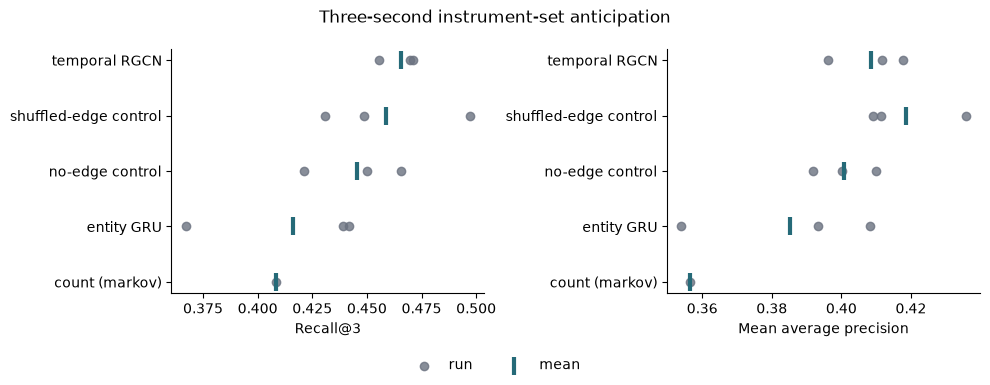

In [9]:
test_labels = torch.stack([example["y"] for example in EXAMPLES["test"]])
test_multi = torch.tensor([example["multi_instrument"] for example in EXAMPLES["test"]])
test_procedures = np.asarray([example["procedure"] for example in EXAMPLES["test"]])
PREDICTIONS = {}
result_rows = []

baseline_prediction = baseline_scores(BASELINE, EXAMPLES["test"])
PREDICTIONS[("count_baseline", 0)] = (baseline_prediction, test_labels, test_multi, test_procedures)
result_rows.append(
    {"cohort": "primary", "condition": f"count_baseline_{BASELINE}", "seed": 0,
     **multilabel_metrics(baseline_prediction, test_labels)}
)

for (condition, seed), (model, _) in RUNS.items():
    if condition == "shuffled_edge_control":
        test_batches = CONTROL_BATCHES[seed]["test"]
    elif condition == "no_edge_control":
        test_batches = NO_EDGE_BATCHES["test"]
    else:
        test_batches = BATCHES["test"]
    prediction = predict_model(model, test_batches)
    PREDICTIONS[(condition, seed)] = prediction
    result_rows.append(
        {"cohort": "primary", "condition": condition, "seed": seed,
         **multilabel_metrics(prediction[0], prediction[1])}
    )

primary_results = pd.DataFrame(result_rows)
primary_summary = (
    primary_results.groupby("condition")
    .agg(
        seeds=("seed", "size"),
        recall_at_1=("recall_at_1", "mean"),
        recall_at_3=("recall_at_3", "mean"),
        mean_average_precision=("mean_average_precision", "mean"),
    )
)
display(primary_summary.round(3))

paired_differences = []
for seed in SEEDS:
    gnn = primary_results.query("condition == 'temporal_rgcn' and seed == @seed").iloc[0]
    gru = primary_results.query("condition == 'entity_gru' and seed == @seed").iloc[0]
    paired_differences.append(
        {"seed": seed, "recall_at_3": gnn.recall_at_3 - gru.recall_at_3,
         "mean_average_precision": gnn.mean_average_precision - gru.mean_average_precision}
    )
paired_differences = pd.DataFrame(paired_differences)
display(paired_differences.round(3))

gru_mean = primary_results.query("condition == 'entity_gru'").mean(numeric_only=True)
gnn_mean = primary_results.query("condition == 'temporal_rgcn'").mean(numeric_only=True)
control_mean = primary_results.query("condition == 'shuffled_edge_control'").mean(numeric_only=True)
no_edge_mean = primary_results.query("condition == 'no_edge_control'").mean(numeric_only=True)
metrics_of_interest = ["recall_at_3", "mean_average_precision"]
graph_vs_entity = gnn_mean[metrics_of_interest] - gru_mean[metrics_of_interest]
graph_vs_no_edge = gnn_mean[metrics_of_interest] - no_edge_mean[metrics_of_interest]
graph_vs_shuffled = gnn_mean[metrics_of_interest] - control_mean[metrics_of_interest]
topology_specific_gain_observed = bool(
    (graph_vs_entity > 0).all() and (graph_vs_no_edge > 0).all() and (graph_vs_shuffled > 0).all()
)
print("graph - entity:", graph_vs_entity.round(3).to_dict())
print("graph - no edge:", graph_vs_no_edge.round(3).to_dict())
print("graph - shuffled:", graph_vs_shuffled.round(3).to_dict())
print("topology-specific gain observed:", topology_specific_gain_observed)

FIGURES_ROOT.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
plot_conditions = [
    "count_baseline_" + BASELINE, "entity_gru", "no_edge_control",
    "shuffled_edge_control", "temporal_rgcn"
]
plot_labels = [
    f"count ({BASELINE})", "entity GRU", "no-edge control",
    "shuffled-edge control", "temporal RGCN"
]
for axis, metric, title in zip(
    axes, ["recall_at_3", "mean_average_precision"], ["Recall@3", "Mean average precision"]
):
    for position, (condition, label) in enumerate(zip(plot_conditions, plot_labels)):
        values = primary_results.query("condition == @condition")[metric]
        point_label = "run" if position == 0 else None
        mean_label = "mean" if position == 0 else None
        axis.scatter(
            values, [position] * len(values), color="#6B7280", alpha=0.8,
            zorder=2, label=point_label
        )
        axis.scatter(
            values.mean(), position, marker="|", s=180, linewidth=3,
            color="#256A78", zorder=3, label=mean_label
        )
    axis.set_yticks(range(len(plot_labels)), plot_labels)
    axis.set_xlabel(title)
    axis.spines[["top", "right"]].set_visible(False)
fig.suptitle("Three-second instrument-set anticipation")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(FIGURES_ROOT / "02_primary_model_comparison.png", dpi=160)
plt.show()

## 8. Sensitivity and uncertainty

The fitted primary models are evaluated again after removing multi-instrument test events. This isolates whether the primary conclusion depends on the small coordinated-onset subset without introducing another round of model selection. Paired hierarchical bootstrap intervals then resample test procedures and training seeds, preserving within-procedure dependence and the paired model comparisons.

In [10]:
singleton_rows = []
for (condition, seed), (scores, labels, multi, procedures) in PREDICTIONS.items():
    keep = ~multi.bool()
    reported_condition = f"count_baseline_{BASELINE}" if condition == "count_baseline" else condition
    singleton_rows.append(
        {"cohort": "singleton_test", "condition": reported_condition, "seed": seed,
         **multilabel_metrics(scores[keep], labels[keep])}
    )

singleton_results = pd.DataFrame(singleton_rows)
singleton_summary = (
    singleton_results.groupby("condition")
    .agg(
        seeds=("seed", "size"),
        recall_at_1=("recall_at_1", "mean"),
        recall_at_3=("recall_at_3", "mean"),
        mean_average_precision=("mean_average_precision", "mean"),
    )
)
display(singleton_summary.round(3))

BOOTSTRAP_REPETITIONS = 2_000
BOOTSTRAP_SEED = 2_026
BOOTSTRAP_METRICS = ["recall_at_3", "mean_average_precision"]


def per_event_metrics(scores, labels):
    ranked_labels = labels.gather(1, scores.argsort(dim=1, descending=True))
    positive_count = labels.sum(dim=1).clamp_min(1)
    recall_at_3 = ranked_labels[:, :3].sum(dim=1) / positive_count
    ranks = torch.arange(1, labels.shape[1] + 1, dtype=torch.float32)
    precision_at_rank = ranked_labels.cumsum(dim=1) / ranks
    average_precision = (precision_at_rank * ranked_labels).sum(dim=1) / positive_count
    return {
        "recall_at_3": recall_at_3.numpy(),
        "mean_average_precision": average_precision.numpy(),
    }


event_metric_contributions = {
    key: per_event_metrics(scores, labels)
    for key, (scores, labels, _, _) in PREDICTIONS.items()
    if key[0] != "count_baseline"
}
for key, contributions in event_metric_contributions.items():
    scores, labels, _, _ = PREDICTIONS[key]
    aggregate = multilabel_metrics(scores, labels)
    for metric in BOOTSTRAP_METRICS:
        assert np.isclose(contributions[metric].mean(), aggregate[metric], atol=1e-6)


def paired_hierarchical_bootstrap(condition_a, condition_b, random_seed):
    rng = np.random.default_rng(random_seed)
    reference_procedures = PREDICTIONS[(condition_a, SEEDS[0])][3]
    unique_procedures = np.unique(reference_procedures)
    draws = {metric: [] for metric in BOOTSTRAP_METRICS}

    for _ in range(BOOTSTRAP_REPETITIONS):
        sampled_procedures = rng.choice(unique_procedures, len(unique_procedures), replace=True)
        sampled_indices = np.concatenate(
            [np.flatnonzero(reference_procedures == procedure) for procedure in sampled_procedures]
        )
        sampled_seeds = rng.choice(SEEDS, len(SEEDS), replace=True)
        for metric in BOOTSTRAP_METRICS:
            paired_seed_differences = [
                event_metric_contributions[(condition_a, int(sampled_seed))][metric][sampled_indices].mean()
                - event_metric_contributions[(condition_b, int(sampled_seed))][metric][sampled_indices].mean()
                for sampled_seed in sampled_seeds
            ]
            draws[metric].append(float(np.mean(paired_seed_differences)))

    return draws


comparison_specs = [
    ("temporal_rgcn", "entity_gru"),
    ("temporal_rgcn", "no_edge_control"),
    ("temporal_rgcn", "shuffled_edge_control"),
]
bootstrap_rows = []
for comparison_index, (condition_a, condition_b) in enumerate(comparison_specs):
    draws = paired_hierarchical_bootstrap(
        condition_a, condition_b, BOOTSTRAP_SEED + comparison_index
    )
    for metric in BOOTSTRAP_METRICS:
        point_estimate = (
            primary_summary.loc[condition_a, metric]
            - primary_summary.loc[condition_b, metric]
        )
        lower, upper = np.quantile(draws[metric], [0.025, 0.975])
        bootstrap_rows.append(
            {
                "comparison": f"{condition_a} - {condition_b}",
                "metric": metric,
                "point_estimate": point_estimate,
                "ci_lower": lower,
                "ci_upper": upper,
                "repetitions": BOOTSTRAP_REPETITIONS,
            }
        )

bootstrap_intervals = pd.DataFrame(bootstrap_rows)
display(bootstrap_intervals.round(3))
bootstrap_intervals.to_csv(RESULTS_ROOT / "02_bootstrap_intervals.csv", index=False)

all_results = pd.concat([primary_results, singleton_results], ignore_index=True)
all_results.to_csv(RESULTS_ROOT / "02_model_comparison.csv", index=False)
result_payload = {
    "selected_count_baseline": BASELINE,
    "primary_summary": primary_summary.reset_index().to_dict(orient="records"),
    "singleton_summary": singleton_summary.reset_index().to_dict(orient="records"),
    "paired_gnn_minus_gru": paired_differences.to_dict(orient="records"),
    "graph_minus_entity": graph_vs_entity.to_dict(),
    "graph_minus_no_edge": graph_vs_no_edge.to_dict(),
    "graph_minus_shuffled": graph_vs_shuffled.to_dict(),
    "bootstrap_intervals": bootstrap_intervals.to_dict(orient="records"),
    "topology_specific_gain_observed": topology_specific_gain_observed,
}
with (RESULTS_ROOT / "02_model_comparison.json").open("w") as file_handle:
    json.dump(result_payload, file_handle, indent=2)
    file_handle.write("\n")
print("saved results/02_model_comparison.*")

,seeds,recall_at_1,recall_at_3,mean_average_precision
condition,,,,
count_baseline_markov,1,0.154,0.417,0.358
entity_gru,3,0.219,0.421,0.387
no_edge_control,3,0.228,0.451,0.404
shuffled_edge_control,3,0.246,0.464,0.421
temporal_rgcn,3,0.227,0.470,0.410


,comparison,metric,point_estimate,ci_lower,ci_upper,repetitions
0,temporal_rgcn - entity_gru,recall_at_3,0.049,-0.008,0.115,2000
1,temporal_rgcn - entity_gru,mean_average_precision,0.023,-0.013,0.062,2000
2,temporal_rgcn - no_edge_control,recall_at_3,0.020,-0.026,0.069,2000
3,temporal_rgcn - no_edge_control,mean_average_precision,0.008,-0.021,0.048,2000
4,temporal_rgcn - shuffled_edge_control,recall_at_3,0.006,-0.048,0.053,2000
5,temporal_rgcn - shuffled_edge_control,mean_average_precision,-0.010,-0.037,0.023,2000


saved results/02_model_comparison.*


## Findings

The temporal RGCN produced higher point estimates than the entity GRU in all three seeds, with mean differences of 0.049 Recall@3 (95% paired hierarchical bootstrap interval: -0.008 to 0.115) and 0.023 mean average precision (-0.013 to 0.062). The no-edge and shuffled-edge controls remained close to the full model, and every control-comparison interval included zero. Within this setup, a topology-specific contribution therefore could not be isolated.

This conclusion is deliberately local to CAT-SG, the event definition, the fixed horizon and the compact models evaluated here. It is not evidence against graph representations in richer multimodal settings. Restricting evaluation to singleton events produced the same ordering, so simultaneous instrument sets do not drive the comparison.

## Follow-up question

The controlled comparison motivates a more targeted question: **under which surgical conditions and with which modalities do structured relational representations provide information complementary to procedural history and surgeon-specific preferences?** One hypothesis is that relational context is most informative at locally ambiguous transitions, while routine transitions are already captured by sequence priors. CAT-SG cannot test the personalisation or multimodal parts of that question; they require richer clinical data and domain context.

## Limitations

This is a public-data mechanism study, not a clinical validation. CAT-SG supplies idealised annotations; a deployed system would first have to infer entities and relations from video. Instrument onset is only a proxy for handover or need. Cataract surgery is highly standardised, the training cohort is small, and no surgeon identity is available. The experiment does not reproduce or assess MITI's multimodal models, in-house data or robotic workflow. Results therefore address one narrow question at one horizon and should not be generalized to personalisation or robotic deployment.

**Implementation choices.** Observation windows use the exact frame bounds exported by notebook 1. Semantic direction is retained through inverse relation types. Edge shuffling is restricted to each frame. The same fitted models are used for the singleton sensitivity analysis. Uncertainty intervals use 2,000 paired hierarchical bootstrap draws over held-out procedures and the three training seeds; they do not cover alternative model specifications or hyperparameters.